In [115]:
import math
import matplotlib.pyplot as plt
import statistics
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import tensorflow as tf
from tensorflow import keras

# **Operations on Words** #
In this section we will explore all operations on words.

In [116]:
file1 = open("final_outcomes\clean_en.txt","r",encoding="utf-8")
file2 = open("final_outcomes\clean_hi.txt","r",encoding="utf-8")

## **Language Model(LM)** ##

To develop and train the model, we should have data and and need to pre-process it. 
In the model we will be training the Neural network model snd model only understands numeric values.
The steps invovled in the Language model are :
1. Tokenization
2. Feature Extraction
3. Model creation
4. Model Training
5. Model test/prediction

### **English Corpus** ###

In [117]:
en_word_tokenizer = Tokenizer()

Now write the data into a list<br>
Because of computation issues here we are taking only 100 sentences

In [118]:
en_word_corpus_list = []
count = 0
for x in file1:
  en_word_corpus_list.append(x.strip())
  count += 1
  if(count == 1000):
    break
file1.seek(0)

0

In [119]:
print(f"English->Length = {len(en_word_corpus_list)}\n Sample = {en_word_corpus_list[0:6]}")

English->Length = 1000
 Sample = ['Two ambulances will be provided in each of these places.', 'New Zealand won two matches and lost once each to Australia and Pakistan.', 'I fell unconsciousness after a while.', 'India will be first largest country in the world to think of that scale.', 'If not on (the ground of) parity but on liberty these boys (Aryan Khan and Merchant) should be granted bailRelease them on bail with strict conditions, Desai argued.', 'No permission given yet.']


**Tokenization**<br>
First we will explore English corpus later we will go to Hindi corpus.

In [120]:
en_word_tokenizer.fit_on_texts(en_word_corpus_list)
en_word_vocab_size = len(en_word_tokenizer.word_index)+1

In [121]:
en_word_vocab_size

3280

**Feature Extraction**<br>
Now we will find the sequence of tokens for each line then we will perform pre-padding .<br>

**Ex:** "she took a small drop too much, i suppose. " will be converted into [5,7,12,109,100,3,45,66,12].

Now using n_gram_sequnce and pre-padding we will make set of sequences from this sequence.

**9-sequences if max_length = 9**<br>
1. [0,0,0,0,0,0,0,5,7]
2. [0,0,0,0,0,0,5,7,12]
3. [0,0,0,0,0,5,7,12,109]
4. [0,0,0,0,5,7,12,109,100]
5. [0,0,0,5,7,12,109,100,3]
6. [0,0,5,7,12,109,100,3,45]
7. [0,5,7,12,109,100,3,45,66]
9. [5,7,12,109,100,3,45,66,12]

Repeat this for all lines in the corpus and append it to a list.



let us consider 2,3,4,5 and 6 word grams

In [122]:
'''en_word_input_sequences = []
for line in en_word_corpus_list:
  token_list = en_word_tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    n_word_gram_sequence = token_list[:i+1]
    en_word_input_sequences.append(n_word_gram_sequence)'''

'en_word_input_sequences = []\nfor line in en_word_corpus_list:\n  token_list = en_word_tokenizer.texts_to_sequences([line])[0]\n  for i in range(1,len(token_list)):\n    n_word_gram_sequence = token_list[:i+1]\n    en_word_input_sequences.append(n_word_gram_sequence)'

In [123]:
len(en_word_corpus_list)

1000

In [124]:
#different for loops for different grams
en_word_input_sequences = []

# Generate 2-grams
for line in en_word_corpus_list:
    token_list = en_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 1):
        n_word_gram_sequence = token_list[i:i+2]
        en_word_input_sequences.append(n_word_gram_sequence)

In [125]:
print(len(en_word_input_sequences),en_word_input_sequences[0])

9873 [43, 642]


In [126]:
# Generate 3-grams
for line in en_word_corpus_list:
    token_list = en_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 2):
        n_word_gram_sequence =token_list[i:i+3]
        en_word_input_sequences.append(n_word_gram_sequence)

In [127]:
print(len(en_word_input_sequences),en_word_input_sequences[-1])

18746 [3278, 113, 3279]


In [128]:
# Generate 4-grams
for line in en_word_corpus_list:
    token_list = en_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 3):
        n_word_gram_sequence = token_list[i:i+4]
        en_word_input_sequences.append(n_word_gram_sequence)

In [129]:
print(len(en_word_input_sequences),en_word_input_sequences[-1])

26625 [3277, 3278, 113, 3279]


In [130]:
# Generate 5-grams
for line in en_word_corpus_list:
    token_list = en_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 4):
        n_word_gram_sequence = token_list[i:i+5]
        en_word_input_sequences.append(n_word_gram_sequence)

In [131]:
print(len(en_word_input_sequences),en_word_input_sequences[-1])

33527 [6, 3277, 3278, 113, 3279]


In [132]:
# Generate 6-grams
for line in en_word_corpus_list:
    token_list = en_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 5):
        n_word_gram_sequence = token_list[i:i+6]
        en_word_input_sequences.append(n_word_gram_sequence)

In [133]:
print(len(en_word_input_sequences),en_word_input_sequences[-1])

39508 [36, 6, 3277, 3278, 113, 3279]


In [134]:
en_max_sequence_len = 6
en_word_input_sequences = np.array(pad_sequences(en_word_input_sequences,maxlen=en_max_sequence_len,padding='pre'))

In [135]:
print(en_word_input_sequences[0:10])
print(len(en_word_input_sequences[0]))

[[   0    0    0    0   43  642]
 [   0    0    0    0  642   12]
 [   0    0    0    0   12   13]
 [   0    0    0    0   13  432]
 [   0    0    0    0  432    3]
 [   0    0    0    0    3  131]
 [   0    0    0    0  131    4]
 [   0    0    0    0    4   71]
 [   0    0    0    0   71  643]
 [   0    0    0    0   54 1142]]
6


In [136]:
en_word_input = en_word_input_sequences[:,:-1]
en_word_output = en_word_input_sequences[:,-1]
print(en_word_input[1])
print(en_word_output[1])

[  0   0   0   0 642]
12


one-hot encoding for the output

In [137]:
en_word_output = tf.keras.utils.to_categorical(en_word_output,num_classes=en_word_vocab_size)
en_word_output[1]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

**Model Creation**<br>

In [138]:
model_en_word = tf.keras.Sequential()
model_en_word.add(tf.keras.layers.Embedding(en_word_vocab_size,64,input_length = en_max_sequence_len -1))
model_en_word.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)))
model_en_word.add(tf.keras.layers.Dense(en_word_vocab_size,activation = 'softmax'))

model_en_word.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_2 (Embedding)     (None, 5, 64)             209920    
                                                                 
 bidirectional_2 (Bidirecti  (None, 40)                13600     
 onal)                                                           
                                                                 
 dense_2 (Dense)             (None, 3280)              134480    
                                                                 
Total params: 358000 (1.37 MB)
Trainable params: 358000 (1.37 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Model Training**<br>

In [139]:
model_en_word.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])
history_en_word = model_en_word.fit(en_word_input,en_word_output,epochs=50,verbose=1)

Epoch 1/50


1235/1235 [==============================] - 12s 7ms/step - loss: 6.8343 - accuracy: 0.0595
Epoch 2/50
1235/1235 [==============================] - 7s 6ms/step - loss: 6.2643 - accuracy: 0.0755
Epoch 3/50
1235/1235 [==============================] - 7s 6ms/step - loss: 5.8813 - accuracy: 0.0996
Epoch 4/50
1235/1235 [==============================] - 8s 6ms/step - loss: 5.5574 - accuracy: 0.1214
Epoch 5/50
1235/1235 [==============================] - 8s 6ms/step - loss: 5.2972 - accuracy: 0.1404
Epoch 6/50
1235/1235 [==============================] - 8s 6ms/step - loss: 5.0659 - accuracy: 0.1567
Epoch 7/50
1235/1235 [==============================] - 8s 6ms/step - loss: 4.8389 - accuracy: 0.1727
Epoch 8/50
1235/1235 [==============================] - 8s 6ms/step - loss: 4.6169 - accuracy: 0.1924
Epoch 9/50
1235/1235 [==============================] - 8s 6ms/step - loss: 4.3936 - accuracy: 0.2133
Epoch 10/50
1235/1235 [==============================] - 8s 6ms/step - loss: 4.1660 - accura

**Training Visualization**<br>

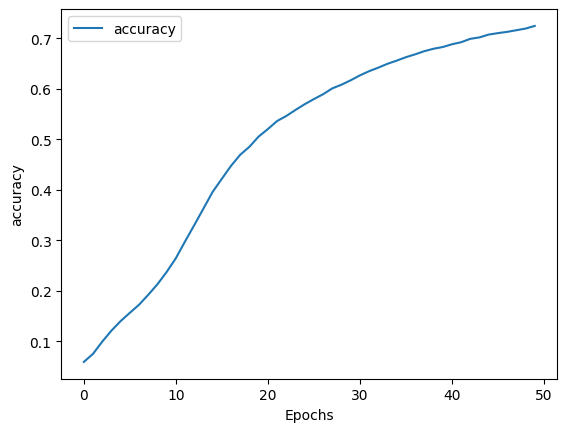

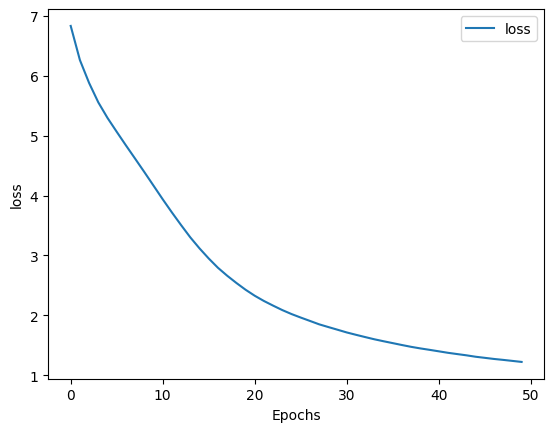

In [153]:
# Plot utility
def plot_graphs(history, string):
  plt.plot(history.history[string])
  plt.xlabel("Epochs")
  plt.ylabel(string)
  plt.legend([string, 'val_'+string])
  plt.show()

# Plot the accuracy and results
plot_graphs(history_en_word, "accuracy")
plot_graphs(history_en_word, "loss")

In [158]:
#save the model
model_en_word.save('en_word_prediction')

INFO:tensorflow:Assets written to: en_word_prediction\assets


INFO:tensorflow:Assets written to: en_word_prediction\assets


In [159]:
#load and predict the next word
loaded_en_word_model = tf.keras.models.load_model('en_word_prediction')


**Next Word Prediction**<br>

In [160]:
#predict the next 10 words
test_text = "Hello guys this is my"
test_tokens = []

test_tokens =  en_word_tokenizer.texts_to_sequences([test_text])[0]
test_tokens = pad_sequences([test_tokens],maxlen=en_max_sequence_len-1,padding='pre')

for i in range(10):
  probabilities = loaded_en_word_model.predict(test_tokens)
  predicted = np.argmax(probabilities,axis = -1)[0]
  output_word = en_word_tokenizer.index_word[predicted]
  test_text = test_text +" "+ output_word

  test_tokens = np.append(test_tokens, [[predicted]], axis=1)
  test_tokens = test_tokens[:,1:]

print(test_text)

1/1 [==============================] - 0s 16ms/step
Hello guys this is my own experience you know he has learnt from the setback


### **Hindi Corpus** ###
Now let us explore next word prediction for Hindi corpus.

**Tokenization**<br>

In [161]:
hi_word_tokenizer = Tokenizer()

In [167]:
hi_word_corpus_list = []
count = 0
for y in file2:
  hi_word_corpus_list.append(y.strip())
  count += 1
  if(count == 1000):
    break
file2.seek(0)

0

In [168]:
print(f"Hindi->Length = {len(hi_word_corpus_list)}\n Sample = {hi_word_corpus_list[0:6]}")

Hindi->Length = 1000
 Sample = ['इसके लिए प्रत्येक थाने में दोदो गाडि़यां उपलब्ध कराई जाएंगी।', 'न्यूजीलैंड को पाकिस्तान और आस्ट्रेलिया के खिलाफ पिछले दो मुकाबलों में हार का सामना करना पड़ा है', 'में कुछु देर बाद बेहोश हो गई।', 'भारत दुनिया में पहला बड़ा देश होगा जो उस पैमाने के बारे में सोचता है।', 'देसाई ने कहा  इन लड़कों आर्यन और मर्चेंट को अगर समानता के आधार पर नहीं तो स्वतंत्रता के आधार पर जमानत दी जानी चाहिएसख्त शर्तों के आधार पर इन्हें जमानत पर रिहा करें।', 'अभी अनुमति नहीं मिली है।']


In [169]:
hi_word_tokenizer.fit_on_texts(hi_word_corpus_list)
hi_word_vocab_size = len(hi_word_tokenizer.word_index)+1

In [170]:
hi_word_vocab_size

3602

**Feature Extraction** <br>

Let's take 2,3,4,5 and 6 grams

In [147]:
'''hi_word_input_sequences = []
for line in hi_word_corpus_list:
  token_list = hi_word_tokenizer.texts_to_sequences([line])[0]
  for i in range(1,len(token_list)):
    n_gram_word_sequence = token_list[:i+1]
    hi_word_input_sequences.append(n_gram_word_sequence)'''

In [171]:
#different for loops for different grams
hi_word_input_sequences = []

# Generate 2-grams
for line in hi_word_corpus_list:
    token_list = hi_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 1):
        n_word_gram_sequence = token_list[i:i+2]
        hi_word_input_sequences.append(n_word_gram_sequence)

In [172]:
print(len(hi_word_input_sequences),hi_word_input_sequences[-1])

11056 [173, 16]


In [173]:
# Generate 3-grams
for line in hi_word_corpus_list:
    token_list = hi_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 2):
        n_word_gram_sequence =token_list[i:i+3]
        hi_word_input_sequences.append(n_word_gram_sequence)

In [174]:
print(len(hi_word_input_sequences),hi_word_input_sequences[-1])

21112 [20, 173, 16]


In [175]:
# Generate 4-grams
for line in hi_word_corpus_list:
    token_list = hi_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 3):
        n_word_gram_sequence = token_list[i:i+4]
        hi_word_input_sequences.append(n_word_gram_sequence)

In [176]:
print(len(hi_word_input_sequences),hi_word_input_sequences[-1])

30172 [3601, 20, 173, 16]


In [177]:
# Generate 5-grams
for line in hi_word_corpus_list:
    token_list = hi_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 4):
        n_word_gram_sequence = token_list[i:i+5]
        hi_word_input_sequences.append(n_word_gram_sequence)

In [178]:
print(len(hi_word_input_sequences),hi_word_input_sequences[-1])

38241 [2, 3601, 20, 173, 16]


In [179]:
# Generate 6-grams
for line in hi_word_corpus_list:
    token_list = hi_word_tokenizer.texts_to_sequences([line])[0]
    for i in range(len(token_list) - 5):
        n_word_gram_sequence = token_list[i:i+6]
        hi_word_input_sequences.append(n_word_gram_sequence)

In [180]:
print(len(hi_word_input_sequences),hi_word_input_sequences[-1])

45347 [3600, 2, 3601, 20, 173, 16]


In [181]:
hi_max_sequence_len = 6
hi_word_input_sequences = np.array(pad_sequences(hi_word_input_sequences,maxlen=hi_max_sequence_len,padding='pre'))

In [182]:
print(hi_word_input_sequences[0:10])
print(len(hi_word_input_sequences[0]))

[[   0    0    0    0   44   13]
 [   0    0    0    0   13  363]
 [   0    0    0    0  363  213]
 [   0    0    0    0  213    2]
 [   0    0    0    0    2  491]
 [   0    0    0    0  491 1233]
 [   0    0    0    0 1233  214]
 [   0    0    0    0  214 1234]
 [   0    0    0    0 1234  701]
 [   0    0    0    0 1235    6]]
6


In [183]:
hi_word_input = hi_word_input_sequences[:,:-1]
hi_word_output = hi_word_input_sequences[:,-1]
print(hi_word_input[1])
print(hi_word_output[1])

[ 0  0  0  0 13]
363


In [184]:
#one-hot encoding
hi_word_output = tf.keras.utils.to_categorical(hi_word_output,num_classes=hi_word_vocab_size)
hi_word_output[1]

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

**Model Creation**<br>

In [185]:
model_hi_word = tf.keras.Sequential()
model_hi_word.add(tf.keras.layers.Embedding(hi_word_vocab_size,64,input_length = hi_max_sequence_len -1))
model_hi_word.add(tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(20)))
model_hi_word.add(tf.keras.layers.Dense(hi_word_vocab_size,activation = 'softmax'))

model_hi_word.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_3 (Embedding)     (None, 5, 64)             230528    
                                                                 
 bidirectional_3 (Bidirecti  (None, 40)                13600     
 onal)                                                           
                                                                 
 dense_3 (Dense)             (None, 3602)              147682    
                                                                 
Total params: 391810 (1.49 MB)
Trainable params: 391810 (1.49 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**Model Training**<br>

In [186]:
model_hi_word.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])
history_hi_word = model_hi_word.fit(hi_word_input,hi_word_output,epochs=50,verbose=1)

Epoch 1/50
1418/1418 [==============================] - 13s 6ms/step - loss: 6.7438 - accuracy: 0.0407
Epoch 2/50
1418/1418 [==============================] - 9s 6ms/step - loss: 6.1037 - accuracy: 0.0642
Epoch 3/50
1418/1418 [==============================] - 10s 7ms/step - loss: 5.7152 - accuracy: 0.0905
Epoch 4/50
1418/1418 [==============================] - 10s 7ms/step - loss: 5.3933 - accuracy: 0.1217
Epoch 5/50
1418/1418 [==============================] - 12s 8ms/step - loss: 5.1334 - accuracy: 0.1468
Epoch 6/50
1418/1418 [==============================] - 11s 8ms/step - loss: 4.8931 - accuracy: 0.1706
Epoch 7/50
1418/1418 [==============================] - 10s 7ms/step - loss: 4.6480 - accuracy: 0.1936
Epoch 8/50
1418/1418 [==============================] - 11s 8ms/step - loss: 4.3943 - accuracy: 0.2168
Epoch 9/50
1418/1418 [==============================] - 11s 8ms/step - loss: 4.1306 - accuracy: 0.2448
Epoch 10/50
1418/1418 [==============================] - 11s 8ms/step - lo

**Training Visualization**<br>

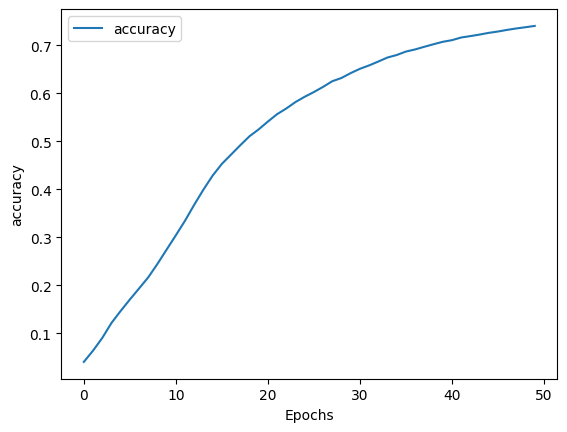

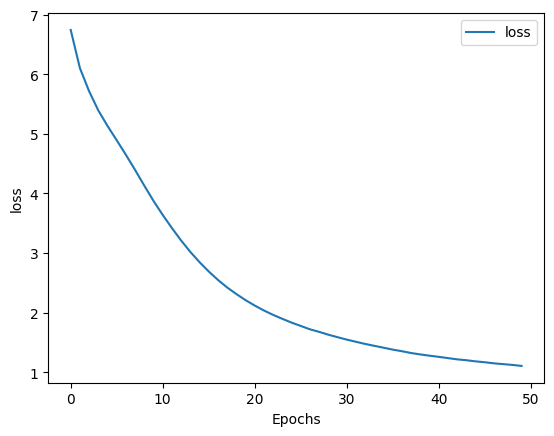

In [187]:
# Plot the accuracy and results
plot_graphs(history_hi_word, "accuracy")
plot_graphs(history_hi_word, "loss")

In [195]:
#save the model
model_hi_word.save('hi_word_prediction')

INFO:tensorflow:Assets written to: hi_word_prediction\assets


INFO:tensorflow:Assets written to: hi_word_prediction\assets


In [196]:
#load and predict the next word
loaded_hi_word_model = tf.keras.models.load_model('hi_word_prediction')

**Prediction**<br>

In [197]:
#predict the next 10 words
test_text = "यह बारिश अभी और"
test_tokens = []

test_tokens =  hi_word_tokenizer.texts_to_sequences([test_text])[0]
test_tokens = pad_sequences([test_tokens],maxlen=en_max_sequence_len-1,padding='pre')

for i in range(10):
  probabilities = loaded_hi_word_model.predict(test_tokens)
  predicted = np.argmax(probabilities,axis = -1)[0]
  output_word = hi_word_tokenizer.index_word[predicted]
  test_text = test_text +" "+ output_word

  test_tokens = np.append(test_tokens, [[predicted]], axis=1)
  test_tokens = test_tokens[:,1:]

print(test_text)

1/1 [==============================] - 0s 17ms/step
यह बारिश अभी और वीडियो से रहा है। हैं और उसके शब्दों के जवाब
